# How The El Niño Southern Oscillation Impacts Average Winter Temperature

## Analyzed With xmACIS2Py

***xmACIS2Py (C) Eric J. Drewitz 2025-2026***

*xmACIS2Py is an open-source Python package that directly interacts with the ACIS2 Web Services API
combined with a large suite of analysis tools to help analyze xmACIS2 data in Python.*

[xmACIS2Py Documentation](https://pypi.org/project/xmacis2py/)

[xmACIS2Py GitHub Repository](https://github.com/edrewitz/xmACIS2Py)

In this example, we will use xmACIS2Py and Pandas to analyze and plot how the El Niño Southern Oscillation impacts the average winter temperature across California and Nevada.  

### Imports

In [1]:
# Imports Needed:
# - xmACIS2Py
# - Matplotlib
# - Pandas
# - NumPy
# - Cartopy
# - os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os

# We need the following from xmACIS2Py:
# - analysis module (Consists of all xmACIS2Py Analysis Tools)
# - get_multi_station_acis_data client function - Downloads and returns a Pandas.DataFrame and/or CSV file of the ACIS2 Data.
# - multi_station_meta client function - Downloads and returns a Pandas.DataFrame and/or CSV file of the ACIS2 Meta-Data.
from xmacis2py import(
    analysis,
    get_multi_station_acis_data,
    multi_station_meta
)

### Downloading Our Data

In [2]:
# List of ASOS Stations across California and Nevada

stations = [
    # --- California ---
    "KACV","KAPC","KAVX","KBFL","KBUR","KCCR","KCIC","KCMA","KCRQ","KDAG",
    "KEDU","KEED","KEKA","KEMT","KFAT","KFUL","KGOO","KHAF","KHHR","KHJO",
    "KHMT","KHWD","KIER","KIPL","KIZA","KJFK","KJNX","KLAX","KLLR","KLMT",
    "KLNK","KLVK","KMAE","KMCC","KMCE","KMER","KMHR","KMHV","KMKE","KMOD",
    "KMRY","KMYF","KMYV","KNFG","KNID","KNKX","KNLC","KNOW","KNTD","KNUQ",
    "KOAK","KOCN","KONT","KOVE","KOXR","KPAO","KPMD","KPRB","KPSP","KRAL",
    "KRDD","KRHV","KRIV","KRNO","KRNM","KROW","KSAC","KSAN","KSBA","KSBD",
    "KSCK","KSFO","KSGX","KSIY","KSMF","KSMO","KSNA","KSQL","KSTS","KSUU",
    "KTOA","KTRK","KTVL","KTWF","KUKI","KVBG","KVCV","KVNY","KWJF",

    # --- Nevada ---
    "KBAM","KBTY","KCXP","KDRA","KEKO","KELY","KHND","KHTH","KINS","KLAS",
    "KLOL","KLSV","KMMH","KNDY","KNFL","KOWY","KPRC","KRNO","KTPH","KTVL",
    "KWMC"
]

In [3]:
# Using xmACIS2Py to retrieve all the available data in the period between 1981-01-01 and 2025-12-31
get_multi_station_acis_data(stations,
                          start_date='1981-01-01',
                          end_date='2025-12-31',
                           to_csv=True,
                           return_pandas_df=False)

KACV Data Saved: XMACIS2 DATA/KACV.csv
KAPC Data Saved: XMACIS2 DATA/KAPC.csv
KAVX Data Saved: XMACIS2 DATA/KAVX.csv
KBFL Data Saved: XMACIS2 DATA/KBFL.csv
KBUR Data Saved: XMACIS2 DATA/KBUR.csv
KCCR Data Saved: XMACIS2 DATA/KCCR.csv
KCIC Data Saved: XMACIS2 DATA/KCIC.csv
KCMA Data Saved: XMACIS2 DATA/KCMA.csv
KCRQ Data Saved: XMACIS2 DATA/KCRQ.csv
KDAG Data Saved: XMACIS2 DATA/KDAG.csv
KEDU not found in database. Skipping...
KEED Data Saved: XMACIS2 DATA/KEED.csv
KEKA Data Saved: XMACIS2 DATA/KEKA.csv
KEMT not found in database. Skipping...
KFAT Data Saved: XMACIS2 DATA/KFAT.csv
KFUL Data Saved: XMACIS2 DATA/KFUL.csv
KGOO not found in database. Skipping...
KHAF not found in database. Skipping...
KHHR Data Saved: XMACIS2 DATA/KHHR.csv
KHJO Data Saved: XMACIS2 DATA/KHJO.csv
KHMT not found in database. Skipping...
KHWD Data Saved: XMACIS2 DATA/KHWD.csv
KIER not found in database. Skipping...
KIPL Data Saved: XMACIS2 DATA/KIPL.csv
KIZA not found in database. Skipping...
KJFK Data Saved: X

In [4]:
# We are now going to extract all the station IDs for the stations that have data.
# The filename is the station ID so we need to extract that and remove the .csv file extension

stations_downloaded = []
for file in os.listdir(f"XMACIS2 DATA"):
    filename = os.path.basename(f"XMACIS2 DATA/{file}")
    filename = f"{filename[0:4]}"
    stations_downloaded.append(filename)

In [5]:
# We need the meta data for each station
# We need the latitude and longitude from this meta data

multi_station_meta(stations_downloaded,
                   to_csv=True,
                   return_pandas_df=False)

KACV.csv saved to XMACIS2 META
KAPC.csv saved to XMACIS2 META
KAVX.csv saved to XMACIS2 META
KBAM.csv saved to XMACIS2 META
KBFL.csv saved to XMACIS2 META
KBUR.csv saved to XMACIS2 META
KCCR.csv saved to XMACIS2 META
KCIC.csv saved to XMACIS2 META
KCMA.csv saved to XMACIS2 META
KCRQ.csv saved to XMACIS2 META
KDAG.csv saved to XMACIS2 META
KDRA.csv saved to XMACIS2 META
KEED.csv saved to XMACIS2 META
KEKA.csv saved to XMACIS2 META
KEKO.csv saved to XMACIS2 META
KELY.csv saved to XMACIS2 META
KFAT.csv saved to XMACIS2 META
KFUL.csv saved to XMACIS2 META
KHHR.csv saved to XMACIS2 META
KHJO.csv saved to XMACIS2 META
KHND.csv saved to XMACIS2 META
KHWD.csv saved to XMACIS2 META
KINS.csv saved to XMACIS2 META
KIPL.csv saved to XMACIS2 META
KJFK.csv saved to XMACIS2 META
KLAS.csv saved to XMACIS2 META
KLAX.csv saved to XMACIS2 META
KLMT.csv saved to XMACIS2 META
KLNK.csv saved to XMACIS2 META
KLOL.csv saved to XMACIS2 META
KLSV.csv saved to XMACIS2 META
KLVK.csv saved to XMACIS2 META
KMAE.csv

### Organzing Our Meta-Data

Here, we will organize our meta-data into one Pandas.DataFrame by doing the following:

1) Use `pd.read_csv()` to create a Pandas.DataFrame for all CSV files in the XMACIS META Folder
2) Use `pd.concat()` to combine the list of Pandas.DataFrames into one Pandas.DataFrame

In [6]:
meta_data_list = []
for file in os.listdir(f"XMACIS2 META"):
    meta = pd.read_csv(f"XMACIS2 META/{file}")
    meta_data_list.append(meta)

meta = pd.concat(meta_data_list, ignore_index=True)

In [7]:
# Rename column "station" to "Station ID"
meta = meta.rename(columns={"station":"Station ID"})

In [8]:
# Meta-Data (Pandas.DataFrame)
meta

,Station ID,Station Name,Station Elevation (ft),State,Latitude,Longitude
0,402,ARCATA EUREKA AP,211.0,CA,40.97844,-124.10479
1,APC,NAPA COUNTY AIRPORT,16.0,CA,38.20750,-122.28041
2,AVX,AVALON CATALINA AP,1565.0,CA,33.40419,-118.41456
3,B23,BATTLE MOUNTAIN 4SE,4505.0,NV,40.61180,-116.89170
4,BFL,BAKERSFIELD AP,490.0,CA,35.43424,-119.05524
...,...,...,...,...,...,...
80,7239,VANDENBERG AFB,369.0,CA,34.71667,-120.56667
81,KVCV,VICTORVILLE SOUTHERN CALIFORNIA INTL AP,2885.0,CA,34.58333,-117.38333
82,KVNY,VAN NUYS AP,785.0,CA,34.21214,-118.49146
83,WJF,LANCASTER,2338.0,CA,34.74121,-118.21255


### Calculating Daily Climatological Normals

In this next section, we will calculate the daily normals for the entire period for each station.

In [9]:
for station, station_id in zip(stations_downloaded, meta['Station ID']):
    analysis.calculate_daily_normals(station_id,
                                     input_path=f"XMACIS2 DATA/{station}.csv",
                                     to_csv=True,
                                     return_pandas_df=False)

### Calculating Daily Departures From Normal "Daily Anomalies"

In this next section, we will calculate the daily departures from normal for each day in the period of record.

In [10]:
for station, station_id in zip(stations_downloaded, meta['Station ID']):
    analysis.calculate_daily_departures(station_id,
                                        ['Average Temperature'],
                                        raw_data_input_path=f"XMACIS2 DATA/{station}.csv",
                                        normals_input_path=f"XMACIS2 DAILY NORMALS/{station_id}.csv",
                                        to_csv=True,
                                        return_pandas_df=False)


### Choosing Our Analogs

In this next section, we will choose our Analogs for the Top 5 El Niño and Top 5 La Niña winter (DJF) periods since 1981.

***Oceanic Niño Index (NOAA)***


<img src="https://github.com/edrewitz/xmACIS2Py-Jupyter-Lab-Tutorials/blob/main/diagrams/oni%20index.png?raw=true" width="400" height="300">

***We will Filter Analog Years for the DJF period for the top 5 El Nino Years and top 5 La Nina Years***

***Top 5 El Nino Years (DJF)***: 1) 2016 = 2.6, 2) 1983 = 2.2, 3) 1998 = 2.2, 4) 2024 = 1.9, 5) 1992 = 1.7.

***Top 5 La Nina Years (DJF)***: 1) 1989 = -1.7, 2) 2000 = -1.7, 3) 2008 = -1.6, 4) 1999 = -1.5, 5) 2011 = -1.3. 

### Filtering Analogs

Here, we filter our El Niño and La Niña Analogs

In [11]:
for station in meta['Station ID']:
    # El Niño
    analysis.filter_analog_years(station,
                                 [(2015, 12), (2016, 1), (2016, 2),
                                 (1982, 12), (1983, 1), (1983, 2),
                                 (1997, 12), (1998, 1), (1998, 2),
                                 (2023, 12), (2024, 1), (2024, 2),
                                 (1991, 12), (1992, 1), (1992, 2)],
                                 input_path=f"XMACIS2 DAILY DEPARTURES/{station}.csv",
                                 to_csv=True,
                                 output_path=f"XMACIS2 ANALOGS/El Nino",
                                 return_pandas_df=False)



    # La Niña
    analysis.filter_analog_years(station,
                                 [(1988, 12), (1989, 1), (1989, 2),
                                 (1999, 12), (2000, 1), (2000, 2),
                                 (2007, 12), (2008, 1), (2008, 2),
                                 (1998, 12), (1999, 1), (1999, 2),
                                 (2010, 12), (2011, 1), (2011, 2)],
                                 input_path=f"XMACIS2 DAILY DEPARTURES/{station}.csv",
                                 to_csv=True,
                                 output_path=f"XMACIS2 ANALOGS/La Nina",
                                 return_pandas_df=False)



### Calculate Weighted Mean Anomalies

***El Nino Years Weights***: 2 for 2016; 1 for 1983; 1 for 1998; 1 for 2024; 1.5 for 1992. 

***La Nina Years Weights***: 2 for 1989; 1 for 2000; 1 for 2008; 1 for 1999; 1.5 for 2011. 

In [12]:
try:
    os.makedirs(f"El Nino Means")
except Exception as e:
    pass

try:
    os.makedirs(f"La Nina Means")
except Exception as e:
    pass

for station in meta['Station ID']:
    nino = pd.read_csv(f"XMACIS2 ANALOGS/EL NINO/{station}.csv")
    nino['Station'] = station

    nino['El Nino Temps Mean'] = analysis.analog_weighted_mean(nino, 
                                                 'Average Temperature_anom',
                                                 [2, 1, 1, 1, 1.5])

    nino.to_csv(f"El Nino Means/{station}.csv")

for station in meta['Station ID']:
    nina = pd.read_csv(f"XMACIS2 ANALOGS/LA NINA/{station}.csv")
    nina['Station'] = station

    nina['La Nina Temps Mean'] = analysis.analog_weighted_mean(nina, 
                                                 'Average Temperature_anom',
                                                 [2, 1, 1, 1, 1.5])

    nina.to_csv(f"La Nina Means/{station}.csv")
    

### Merge Pandas.DataFrames (Meta-Data & Anomalies)

Here, we will create a new Pandas.DataFrame that has the following:

1) Station ID
2) Latitude
3) Longitude
4) Anomaly

In [13]:
nino_anoms = []
for station in meta['Station ID']:
    df = pd.read_csv(f"El Nino Means/{station}.csv")
    nino_anom = df['El Nino Temps Mean'][0]
    nino_anoms.append(nino_anom)

el_nino = pd.DataFrame({
    "Station ID": meta['Station ID'],
    "anomaly": nino_anoms
})

In [14]:
nina_anoms = []
for station in meta['Station ID']:
    df = pd.read_csv(f"La Nina Means/{station}.csv")
    nina_anom = df['La Nina Temps Mean'][0]
    nina_anoms.append(nina_anom)

la_nina = pd.DataFrame({
    "Station ID": meta['Station ID'],
    "anomaly": nina_anoms
})

In [15]:
el_nino

,Station ID,anomaly
0,402,2.574312
1,APC,1.650296
2,AVX,NaN
3,B23,0.700545
4,BFL,0.017526
...,...,...
80,7239,1.247083
81,KVCV,NaN
82,KVNY,NaN
83,WJF,1.644684


In [16]:
la_nina

,Station ID,anomaly
0,402,-0.037836
1,APC,-0.375796
2,AVX,NaN
3,B23,0.418929
4,BFL,-1.602399
...,...,...
80,7239,-1.924883
81,KVCV,NaN
82,KVNY,NaN
83,WJF,NaN


In [17]:
el_nino = el_nino.merge(
    meta[["Station ID", "Latitude", "Longitude"]],
    on="Station ID",
    how="left"
)

In [18]:
el_nino = el_nino.dropna()

In [19]:
el_nino

,Station ID,anomaly,Latitude,Longitude
0,402,2.574312,40.97844,-124.10479
1,APC,1.650296,38.20750,-122.28041
3,B23,0.700545,40.61180,-116.89170
4,BFL,0.017526,35.43424,-119.05524
5,BUR,1.061939,34.19966,-118.36543
...,...,...,...,...
81,KTWF,1.408937,42.47849,-114.47744
83,7239,1.247083,34.12407,-119.12281
84,7239,1.247083,34.71667,-120.56667
87,WJF,1.644684,34.74121,-118.21255


In [20]:
la_nina = la_nina.merge(
    meta[["Station ID", "Latitude", "Longitude"]],
    on="Station ID",
    how="left"
)

In [21]:
la_nina = la_nina.dropna()

In [22]:
la_nina

,Station ID,anomaly,Latitude,Longitude
0,402,-0.037836,40.97844,-124.10479
1,APC,-0.375796,38.20750,-122.28041
3,B23,0.418929,40.61180,-116.89170
4,BFL,-1.602399,35.43424,-119.05524
5,BUR,-0.873175,34.19966,-118.36543
...,...,...,...,...
79,7258,-1.601295,39.32000,-120.13944
81,KTWF,0.898400,42.47849,-114.47744
83,7239,-1.924883,34.12407,-119.12281
84,7239,-1.924883,34.71667,-120.56667


### Plot Our Data

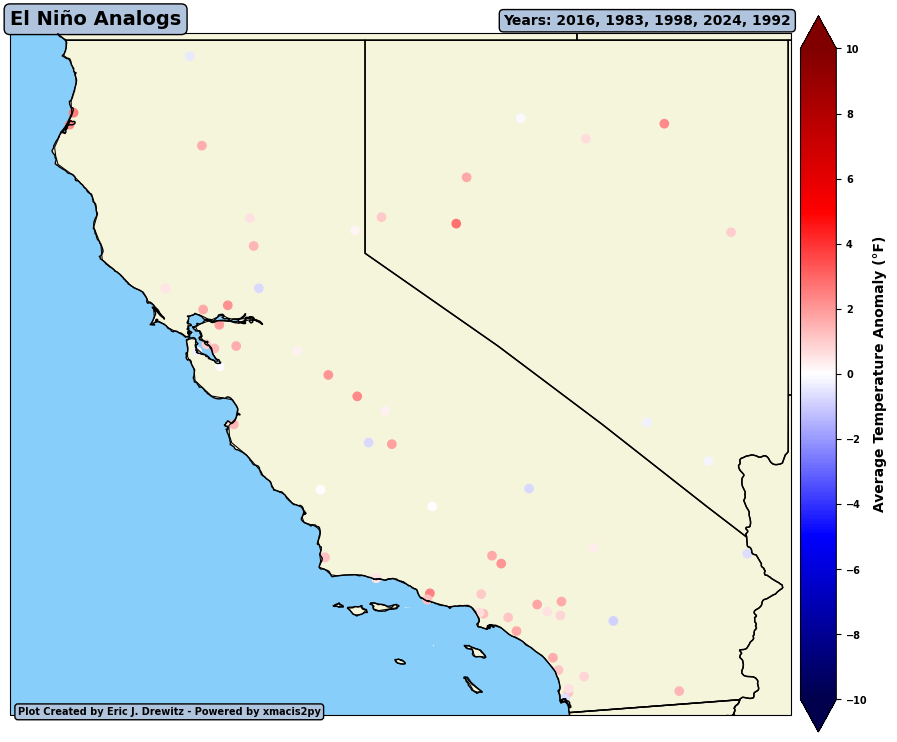

In [23]:
fig = plt.figure(figsize=(12,12))
box = dict(boxstyle='round', facecolor='lightsteelblue')
ax = fig.add_subplot(1,1,1, projection=ccrs.PlateCarree())
# Set our bounds and data coordinate reference system
ax.set_extent([-125, -114, 32.5, 42.1], ccrs.PlateCarree())

# Add coastlines for the outline of the coasts
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.75, zorder=9)

# Add our country borders
ax.add_feature(cfeature.BORDERS, linestyle='-', zorder=2)
ax.add_feature(cfeature.STATES, linestyle='-', zorder=2)
ax.add_feature(cfeature.LAND, facecolor='beige', zorder=1)
ax.add_feature(cfeature.OCEAN, facecolor='lightskyblue', zorder=1)
ax.set_title(f"El Niño Analogs", fontsize=14, fontweight='bold', loc='left', bbox=box)
ax.set_title(f"Years: 2016, 1983, 1998, 2024, 1992", fontsize=10, fontweight='bold', loc='right', bbox=box)
ax.text(0.01, 0, f"Plot Created by Eric J. Drewitz - Powered by xmacis2py", fontsize=7, zorder=10, fontweight='bold', transform=ax.transAxes, bbox=box)
sc = ax.scatter(el_nino['Longitude'], el_nino['Latitude'], c=el_nino['anomaly'], cmap='seismic',
                norm=mcolors.Normalize(vmin=-10, vmax=10, clip=True))
cbar = fig.colorbar(sc, ax=ax, extend='both', pad=0.01, shrink=0.775)
cbar.set_ticks(np.arange(-10, 12, 2))
cbar.set_label("Average Temperature Anomaly (°F)", fontweight='bold', fontsize=10)

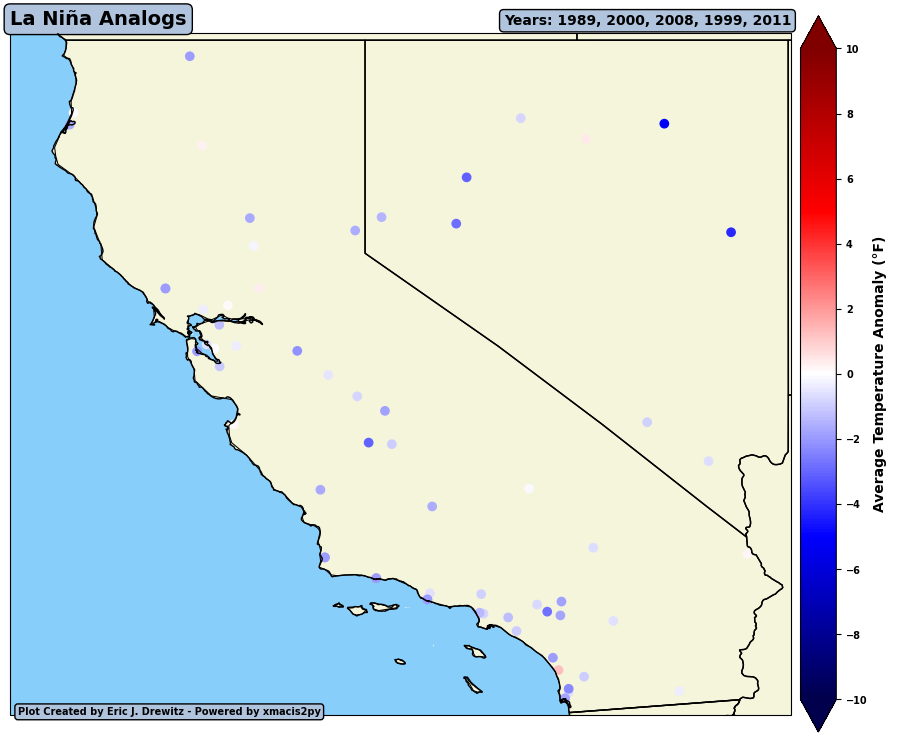

In [24]:
fig = plt.figure(figsize=(12,12))
box = dict(boxstyle='round', facecolor='lightsteelblue')
ax = fig.add_subplot(1,1,1, projection=ccrs.PlateCarree())
# Set our bounds and data coordinate reference system
ax.set_extent([-125, -114, 32.5, 42.1], ccrs.PlateCarree())

# Add coastlines for the outline of the coasts
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.75, zorder=9)

# Add our country borders
ax.add_feature(cfeature.BORDERS, linestyle='-', zorder=2)
ax.add_feature(cfeature.STATES, linestyle='-', zorder=2)
ax.add_feature(cfeature.LAND, facecolor='beige', zorder=1)
ax.add_feature(cfeature.OCEAN, facecolor='lightskyblue', zorder=1)
ax.set_title(f"La Niña Analogs", fontsize=14, fontweight='bold', loc='left', bbox=box)
ax.set_title(f"Years: 1989, 2000, 2008, 1999, 2011", fontsize=10, fontweight='bold', loc='right', bbox=box)
ax.text(0.01, 0, f"Plot Created by Eric J. Drewitz - Powered by xmacis2py", fontsize=7, zorder=10, fontweight='bold', transform=ax.transAxes, bbox=box)
sc = ax.scatter(la_nina['Longitude'], la_nina['Latitude'], c=la_nina['anomaly'], cmap='seismic',
                norm=mcolors.Normalize(vmin=-10, vmax=10, clip=True))
cbar = fig.colorbar(sc, ax=ax, extend='both', pad=0.01, shrink=0.775)
cbar.set_ticks(np.arange(-10, 12, 2))
cbar.set_label("Average Temperature Anomaly (°F)", fontweight='bold', fontsize=10)